In [2]:
import pandas as pd
import numpy as np
import json
import math 
import matplotlib.pyplot as plt
from scipy.stats import ranksums

from visualize_AngioScore_ccRCC import plot_pbrm1_box_strip_by_dataset

def ensembl_to_hugo(col, mapping):
    ensembl_id = col.split('.')[0]
    hugo = mapping.get(ensembl_id, [col])
    return str(hugo[0])


with open("../ccRCC/Data/mapping_genes.json", "r") as f:
    genes_mapping = json.load(f)


genes_mapping = {k: [v[0]] if len(v) > 1 and isinstance(v[0], str) else v 
                 for k, v in genes_mapping.items() 
                 if not (isinstance(v[0], float) and math.isnan(v[0]))}

or_data = pd.read_csv("../ccRCC/Data/original_data.csv", index_col=0)
genes_cols = [col for col in or_data.columns if col.startswith("ENSG")]

seeds = [0, 1, 2, 3, 42]

for seed in seeds:
    print(f"--- Processing Seed: {seed} ---")
    
   
    dataset_dict = {'Original Data': or_data}
    syn_datas = [f"avatarsk5_{seed}", f"avatarsk10_{seed}", f"ctgan_{seed}", f"gaussiancopula_{seed}", f"synthpop_{seed}"]
    
    for syn in syn_datas:
        try:
            dataset_dict[syn] = pd.read_csv(f"../ccRCC/Data/{syn}.csv", index_col=0)
        except FileNotFoundError:
            print(f"Warning: File {syn}.csv not found.")

    symbols_dataset_dict = {}
    for tool, data in dataset_dict.items():
        present_genes_cols = [c for c in genes_cols if c in data.columns]
        genes_exp_df = data[present_genes_cols].copy()
        
      
        genes_exp_df.columns = [ensembl_to_hugo(col, genes_mapping) for col in genes_exp_df.columns]
        
       
        drop_cols = [col for col in genes_exp_df.columns if col.startswith("ENSG")]
        genes_exp_df = genes_exp_df.drop(columns=drop_cols)

       
        genes_exp_df_t = genes_exp_df.T.reset_index()
        genes_exp_df_t.columns.values[0] = 'Gene'
        symbols_dataset_dict[tool] = genes_exp_df_t.groupby("Gene", as_index=False).mean()

    # Calculate Angio Score
    Angio_dict = {}
    methods_display = ["Original Data", "Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop"]
    internal_keys = list(dataset_dict.keys()) 

    for i, key in enumerate(internal_keys):
        angio_sig = ['VEGFA', 'KDR', 'ESM1', 'PECAM1', 'ANGPTL4', 'CD34']
        exp_mat = symbols_dataset_dict[key]
        
        
        angio_exp_mat = exp_mat[exp_mat['Gene'].isin(angio_sig)].set_index('Gene').T
        angio_score = angio_exp_mat.mean(axis=1)
        
        
        mut_idx = dataset_dict[key][dataset_dict[key]['PBRM1'] == "MUT"].index
        wt_idx = dataset_dict[key][dataset_dict[key]['PBRM1'] == "WT"].index
        
        Angio_dict[methods_display[i]] = {
            "PBRM1 \n mutation": angio_score[mut_idx].tolist(),
            "PBRM1 \n wildtype": angio_score[wt_idx].tolist()
        }

    
    fig, ax, stats_df = plot_pbrm1_box_strip_by_dataset(
        dataset_to_groups=Angio_dict,
        value_label="Angiogenesis score",
        title='',
        dataset_order=methods_display,
        group_order=("PBRM1 \n mutation", "PBRM1 \n wildtype"),
        figsize=(18, 6),
    )
    
    output_path = f"AngioScore_ccRCC/Angiogenesis_{seed}.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

--- Processing Seed: 0 ---
--- Processing Seed: 1 ---
--- Processing Seed: 2 ---
--- Processing Seed: 3 ---
--- Processing Seed: 42 ---


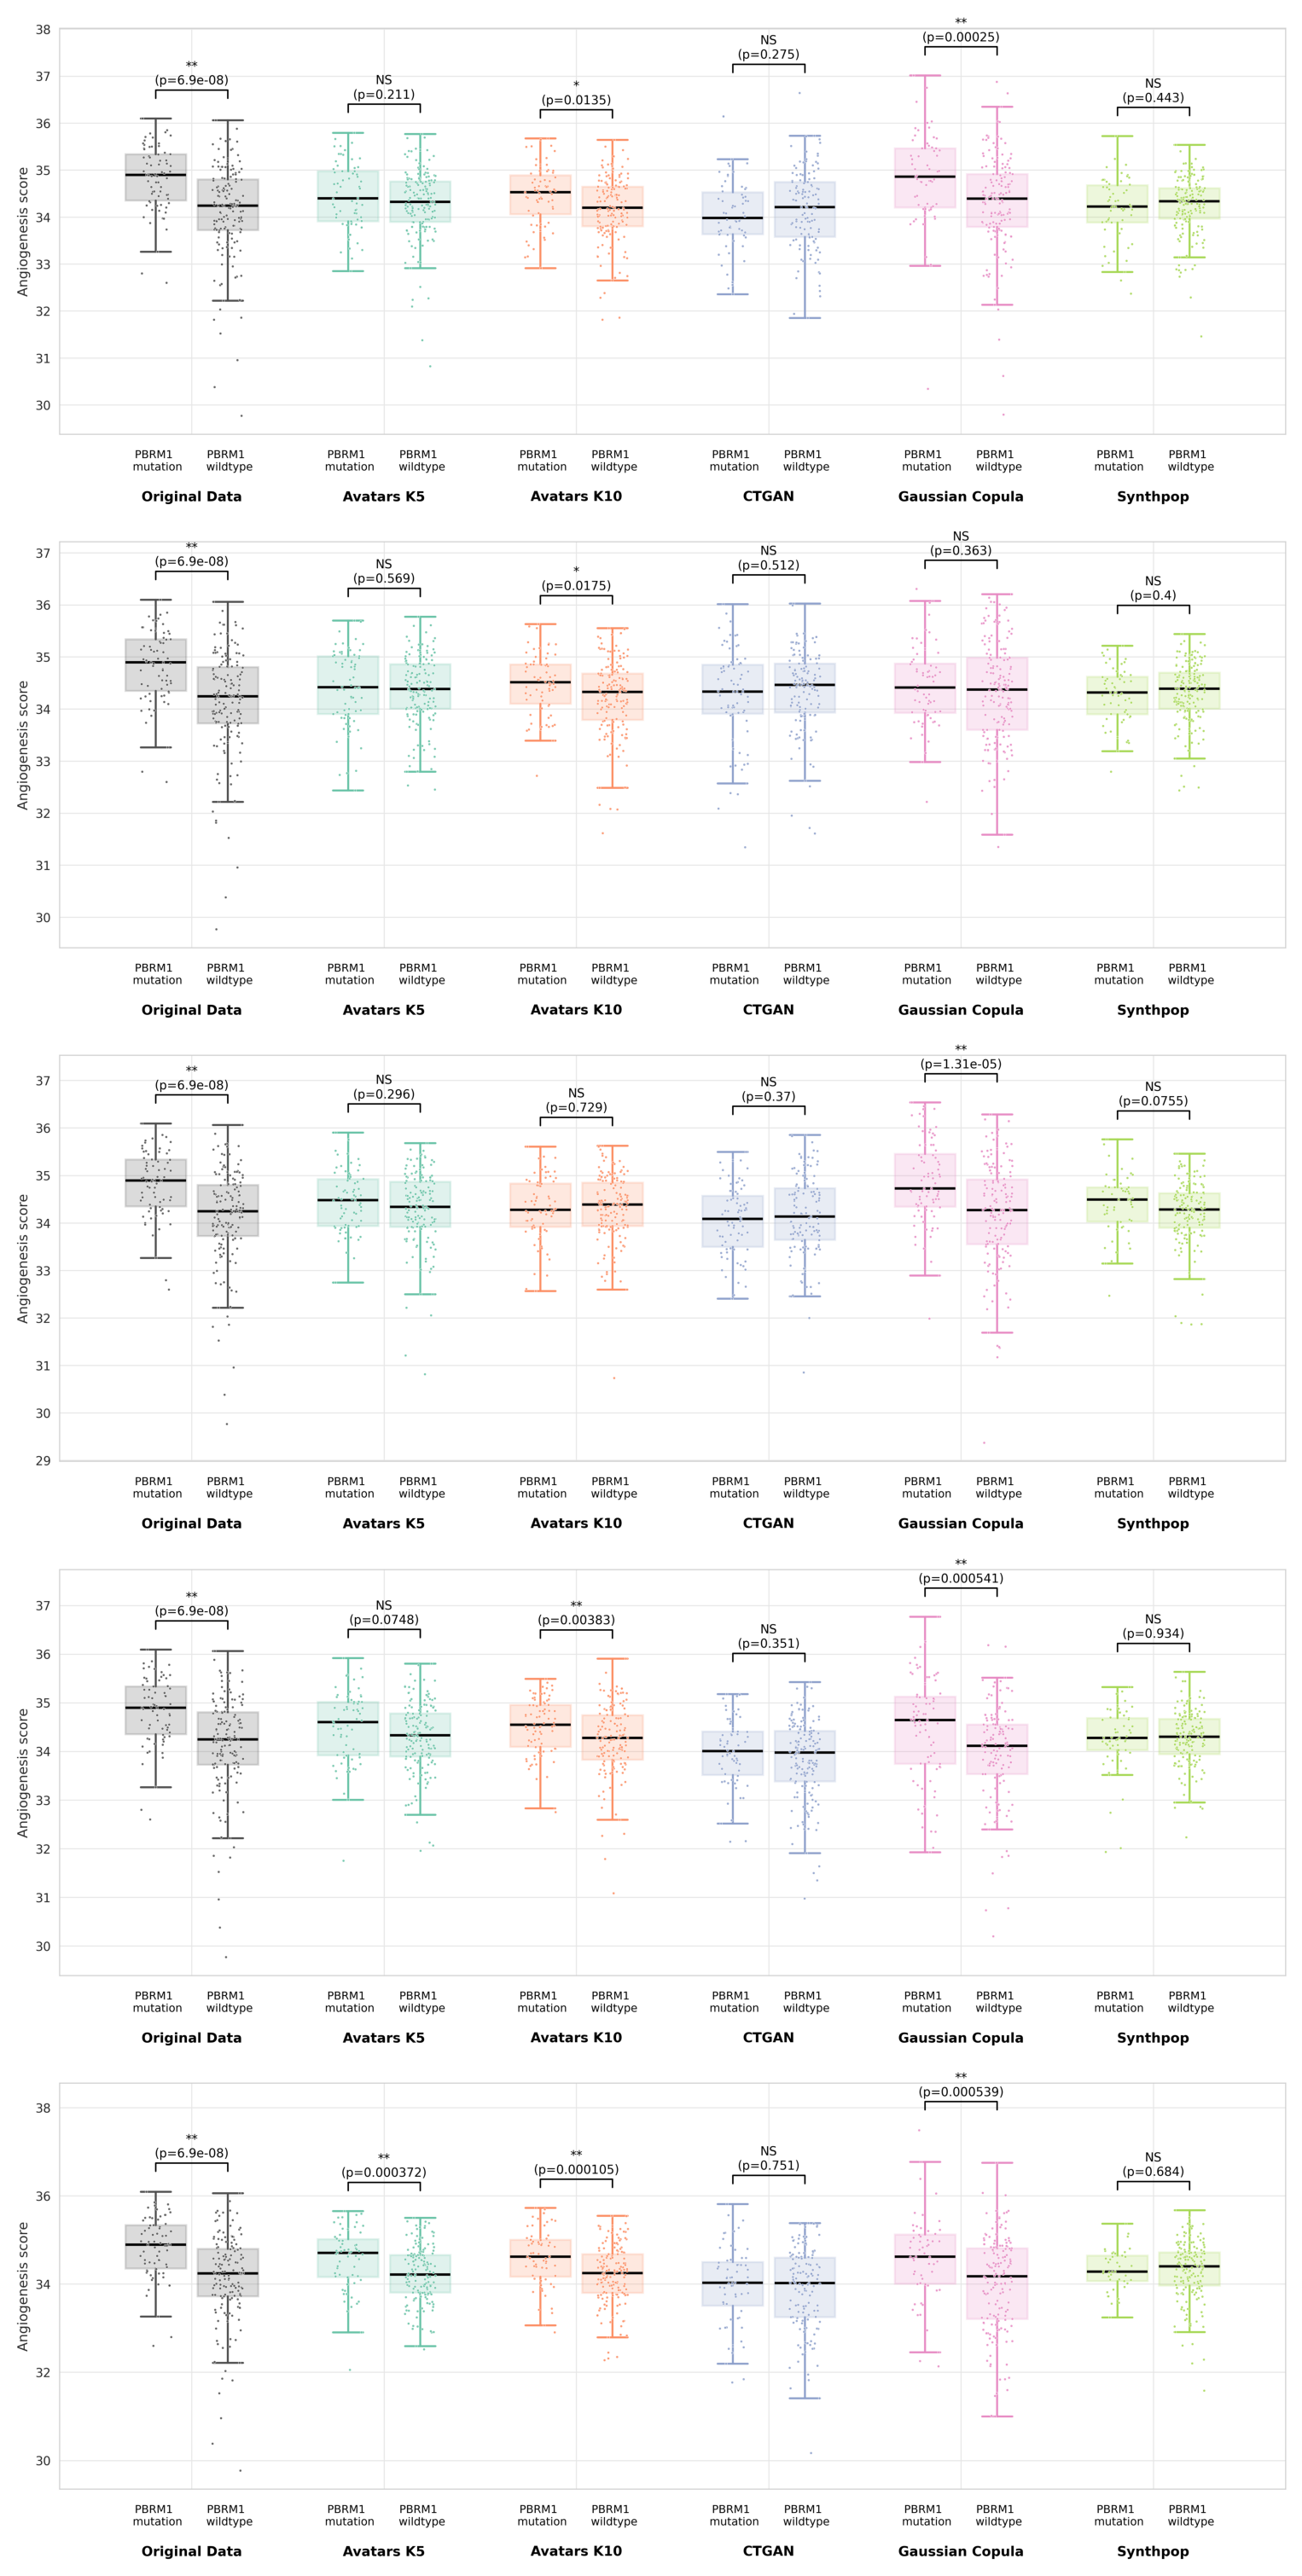

In [3]:
import matplotlib.image as mpimg
from matplotlib import gridspec

fig = plt.figure(figsize=(18, 30))

n_rows = 5
n_cols = 1

gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig,
    wspace=0,   
    hspace=0.02 
)

def show_img(ax, path):
    try:
        img = mpimg.imread(path)
        ax.imshow(img)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f"Missing:\n{path}", ha='center', va='center')
    ax.axis("off")

for i, seed in enumerate(seeds):
    row = i 
    col = 0
    
    path = f"AngioScore_ccRCC/Angiogenesis_{seed}.png"
    ax = fig.add_subplot(gs[row, col])
    show_img(ax, path)


plt.subplots_adjust(left=0, right=1, top=1, bottom=0) 
fig.savefig("AngioScore_ccRCC/Combined_1x5_Vertical.png", dpi=300, bbox_inches="tight")
plt.show()